# Customer Intelligence & Segmentation Platform

## Notebook 05: Customer Segment Profiling & Business Intelligence

### Objective

Analyze customer segments and generate actionable business insights.

### Goals

- Understand segment behavior
- Measure revenue contribution
- Compare customer value
- Develop business recommendations
- Create executive-ready insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
df = pd.read_csv(
    "../data/processed/segmented_customers.csv"
)

df.head()

,CustomerID,Recency,Frequency,Monetary,Avg_Order_Value,Product_Diversity,Tenure,Avg_Basket_Size,Cluster,Segment
0,12346,326,1,77183.60,77183.600000,1,0,74215.000000,2,Wholesale Buyers
1,12347,2,7,4310.00,615.714286,103,365,13.505495,0,Loyal Customers
2,12348,75,4,1797.24,449.310000,22,282,75.516129,0,Loyal Customers
3,12349,19,1,1757.55,1757.550000,73,0,8.643836,3,Potential Loyalists
4,12350,310,1,334.40,334.400000,17,0,11.588235,1,Dormant Customers


In [3]:
print(df.shape)

df.info()

(4338, 10)
<class 'pandas.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         4338 non-null   int64  
 1   Recency            4338 non-null   int64  
 2   Frequency          4338 non-null   int64  
 3   Monetary           4338 non-null   float64
 4   Avg_Order_Value    4338 non-null   float64
 5   Product_Diversity  4338 non-null   int64  
 6   Tenure             4338 non-null   int64  
 7   Avg_Basket_Size    4338 non-null   float64
 8   Cluster            4338 non-null   int64  
 9   Segment            4338 non-null   str    
dtypes: float64(3), int64(6), str(1)
memory usage: 339.0 KB


# Segment Distribution

Analyze how customers are distributed across segments.

In [5]:
segment_counts = (
    df["Segment"]
    .value_counts()
)

segment_counts

Segment
Potential Loyalists    1871
Loyal Customers        1470
Dormant Customers       979
VIP Customers            16
Wholesale Buyers          2
Name: count, dtype: int64

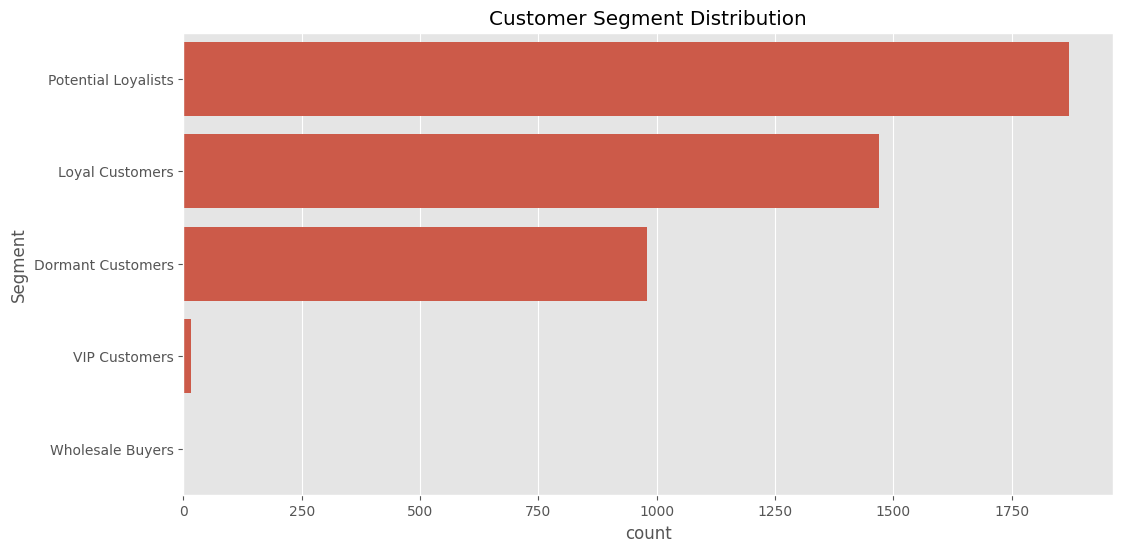

In [6]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="Segment",
    order=segment_counts.index
)

plt.title("Customer Segment Distribution")

plt.show()

# Revenue Contribution by Segment

In [7]:
segment_revenue = (
    df.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

Segment
Loyal Customers        5048145.101
VIP Customers          1678778.830
Potential Loyalists    1387461.092
Dormant Customers       527167.771
Wholesale Buyers        245656.100
Name: Monetary, dtype: float64

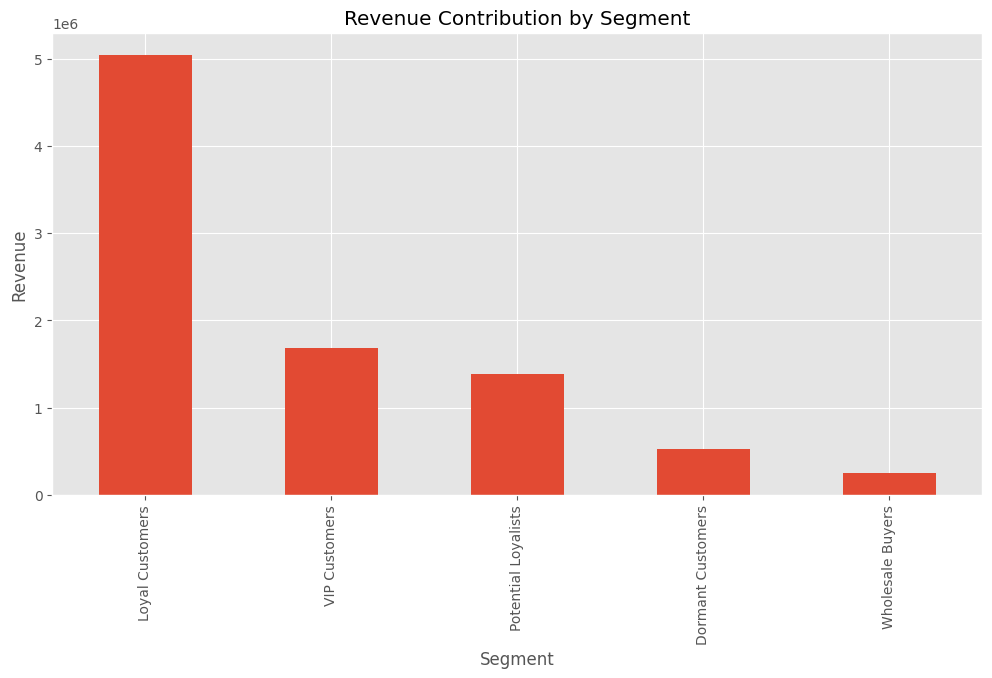

In [8]:
plt.figure(figsize=(12,6))

segment_revenue.plot(
    kind="bar"
)

plt.title("Revenue Contribution by Segment")

plt.ylabel("Revenue")

plt.show()

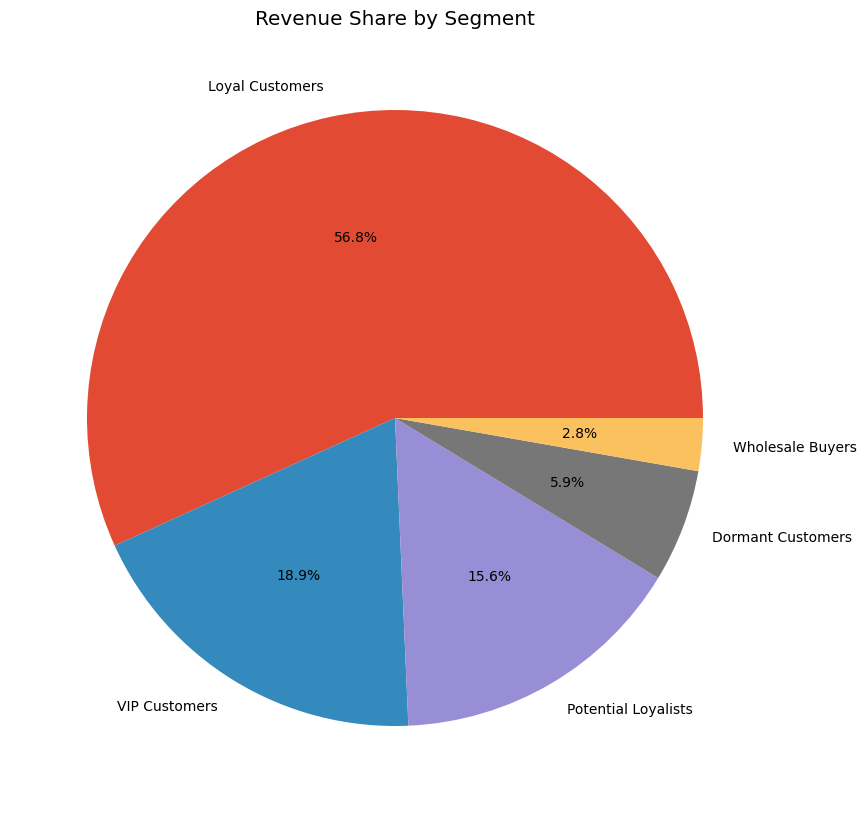

In [9]:
plt.figure(figsize=(10,10))

plt.pie(
    segment_revenue,
    labels=segment_revenue.index,
    autopct="%1.1f%%"
)

plt.title("Revenue Share by Segment")

plt.show()

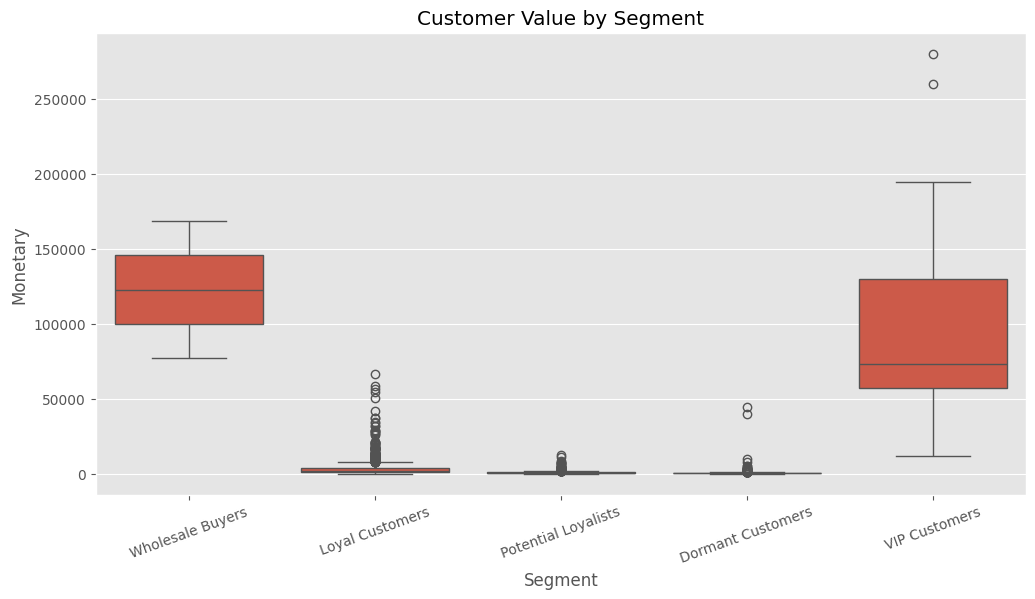

In [10]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Segment",
    y="Monetary"
)

plt.xticks(rotation=20)

plt.title("Customer Value by Segment")

plt.show()

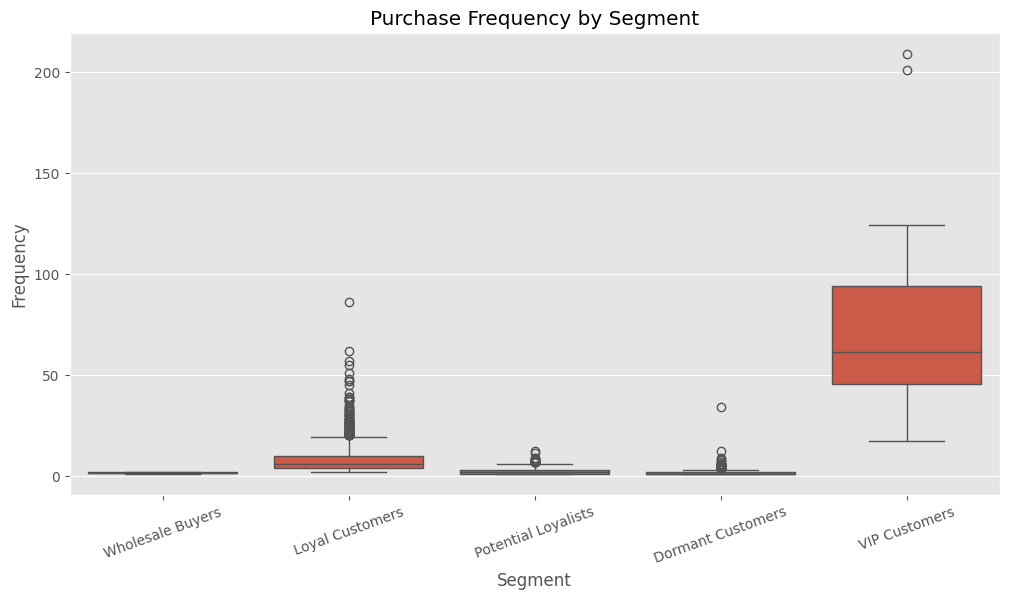

In [11]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Segment",
    y="Frequency"
)

plt.xticks(rotation=20)

plt.title("Purchase Frequency by Segment")

plt.show()

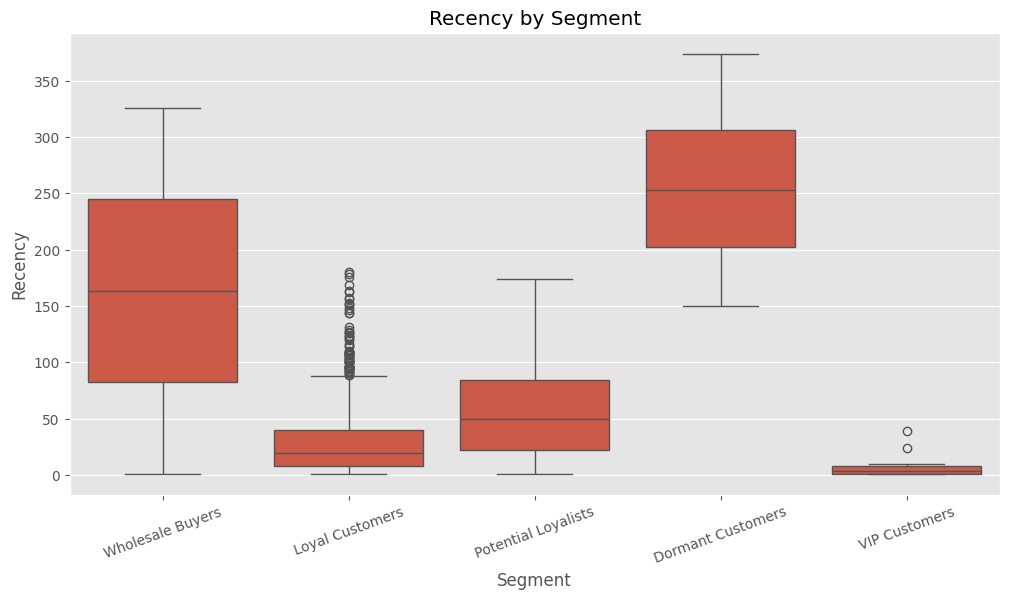

In [12]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Segment",
    y="Recency"
)

plt.xticks(rotation=20)

plt.title("Recency by Segment")

plt.show()

In [13]:
segment_profile = (
    df.groupby("Segment")
    .agg({
        "Recency":"mean",
        "Frequency":"mean",
        "Monetary":"mean",
        "Avg_Order_Value":"mean",
        "Product_Diversity":"mean",
        "Tenure":"mean"
    })
    .round(2)
)

segment_profile

,Recency,Frequency,Monetary,Avg_Order_Value,Product_Diversity,Tenure
Segment,,,,,,
Dormant Customers,256.71,1.50,538.48,338.70,23.21,20.62
Loyal Customers,28.88,8.05,3434.11,407.74,111.36,288.53
Potential Loyalists,57.30,2.11,741.56,366.52,36.59,61.92
VIP Customers,7.00,79.69,104923.68,2099.95,743.62,343.81
Wholesale Buyers,163.50,1.50,122828.05,80709.92,2.00,102.00


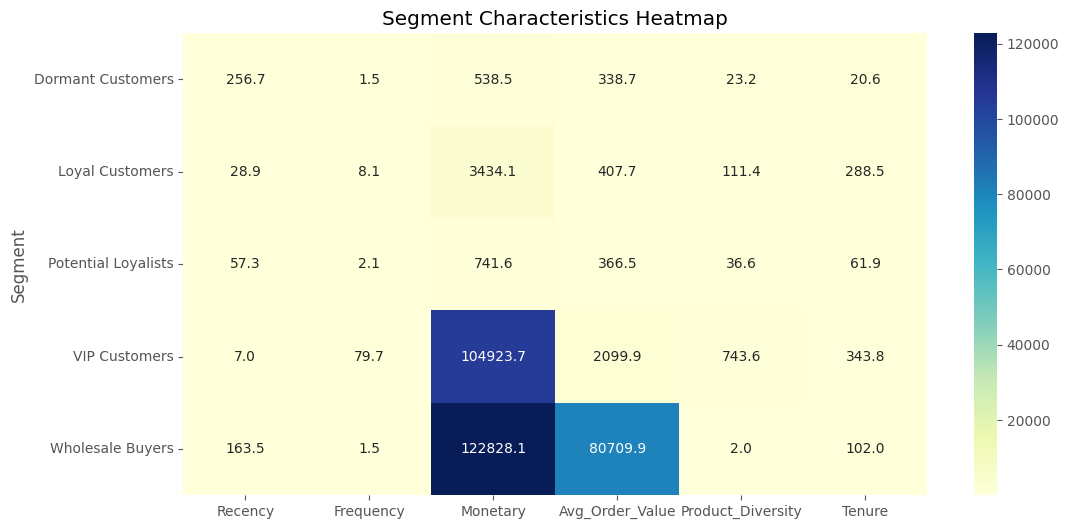

In [14]:
plt.figure(figsize=(12,6))

sns.heatmap(
    segment_profile,
    annot=True,
    cmap="YlGnBu",
    fmt=".1f"
)

plt.title("Segment Characteristics Heatmap")

plt.show()

# Business Recommendations

## VIP Customers

- Offer premium loyalty programs
- Early access to products
- Personalized offers

## Loyal Customers

- Encourage upselling
- Reward repeat purchases
- Referral programs

## Potential Loyalists

- Targeted promotions
- Email campaigns
- Product recommendations

## Wholesale Buyers

- Dedicated account management
- Bulk discounts
- Business partnerships

## Dormant Customers

- Re-engagement campaigns
- Win-back discounts
- Personalized reminders

# Executive Summary

## Key Findings

### VIP Customers
Highest value customers generating substantial revenue.

### Loyal Customers
Consistent repeat buyers with strong engagement.

### Potential Loyalists
Customers with growth potential through targeted marketing.

### Wholesale Buyers
Low-frequency but extremely high-value bulk purchasers.

### Dormant Customers
Inactive customers requiring retention efforts.

## Strategic Impact

Customer segmentation enables:

- Personalized marketing
- Improved retention
- Higher customer lifetime value
- Better resource allocation
- Revenue growth

In [15]:
import os

os.makedirs(
    "../outputs/exports",
    exist_ok=True
)

In [16]:
segment_profile.to_csv(
    "../outputs/exports/segment_profile.csv"
)

print("Segment Profile Saved")

Segment Profile Saved
